# Lab 02 — Open the box

Week 2 · AI course · Narxoz University · about 50 minutes · **no API key**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/unreal-kz/lab-02-AI-course/blob/main/lab02_inside_the_model.ipynb)

Lecture 3 told you what happens inside a language model. Today you check it, on a real model:
GPT-2 small, 124 million parameters, released in 2019. It runs on the free CPU that Colab gives you.
Three claims from the lecture get tested:

1. The output is not a word. It is a list of 50,257 probabilities.
2. Temperature reshapes that list. It cannot change which token is first. Top-p is a different operation.
3. Attention is a table of weights, and every row of it sums to one.

**The rule of this lab, inherited from Lab 01: write your prediction down *before* you run the cell.**
A prediction you did not write down is a prediction you will not remember getting wrong.

**Right now, run the next cell only** (click it, press Shift+Enter). It downloads the model while the
lecture continues. Do **not** use *Run all*: it would show you every answer before you have predicted it.
If a warning about `HF_TOKEN` appears, ignore it — the model is public.

Your answers go in the cells marked ✏️. Double-click a cell to edit it, Shift+Enter to save it.

In [1]:
import importlib.util
import subprocess
import sys

# Colab normally has all three already; this installs whatever is missing.
for pkg in ("torch", "transformers", "matplotlib"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math

import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "openai-community/gpt2"

tok = AutoTokenizer.from_pretrained(MODEL)
# attn_implementation="eager" is required for Part 2: the default "sdpa" kernel never
# returns attention weights, so output_attentions=True would give you nothing.
model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print(f"parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"vocabulary      : {cfg.vocab_size:,} tokens")
print(f"layers x heads  : {cfg.n_layer} x {cfg.n_head}")
print(f"embedding table : {tuple(model.transformer.wte.weight.shape)}  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

torch 2.11.0+cpu | transformers 5.16.1
parameters      : 124,439,808
vocabulary      : 50,257 tokens
layers x heads  : 12 x 12
embedding table : (50257, 768)  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)


## Part 0 — a token is not a word (4 min)

Lecture 3 measured six tokenizers. GPT-2's is the seventh, and the smallest: 50,257 entries, against
100,277 (cl100k), 128,000 (Llama 3) and 200,019 (o200k).

**✏️ Predict first.** The Kazakh word `бөлімшеңізде` took 12 tokens on cl100k and 7 on o200k.
How many will it take on GPT-2: more than 12, fewer, or the same? Write your number here:

> **Prediction:** More than 12 tokens (around 18 tokens)

In [2]:
def show_tokens(text: str) -> None:
    ids = tok.encode(text)
    print(f"{text!r}: {len(ids)} tokens")
    print("  ids   :", ids)
    print("  pieces:", tok.convert_ids_to_tokens(ids))


for word in ["restore", "bank", "банк", "бөлімшеңізде"]:
    show_tokens(word)

'restore': 2 tokens
  ids   : [2118, 382]
  pieces: ['rest', 'ore']
'bank': 1 tokens
  ids   : [17796]
  pieces: ['bank']
'банк': 5 tokens
  ids   : [140, 109, 16142, 22177, 31583]
  pieces: ['Ð', '±', 'Ð°', 'Ð½', 'Ðº']
'бөлімшеңізде': 19 tokens
  ids   : [140, 109, 143, 102, 30143, 141, 244, 43108, 141, 230, 16843, 142, 96, 141, 244, 140, 115, 43666, 16843]
  pieces: ['Ð', '±', 'Ó', '©', 'Ð»', 'Ñ', 'ĸ', 'Ð¼', 'Ñ', 'Ī', 'Ðµ', 'Ò', '£', 'Ñ', 'ĸ', 'Ð', '·', 'Ð´', 'Ðµ']


`Ġ` in a piece means "this token starts with a space". The odd letters (`Ð`, `±` …) are single **bytes**
of a Cyrillic letter, printed as if they were characters — the same thing lecture slide 5 showed for `ө`.

**✏️ Your answer.** In the lecture's board derivation, three merges turned `банк` into one token.
GPT-2 needed several tokens for it. Using what slide 6 taught about where merges come from, why?

> **Answer:** BPE merges are learned during training based on how frequently byte/character pairs appear together in the corpus. GPT-2 was trained almost exclusively on English text (WebText), so byte combinations representing Cyrillic characters in words like "банк" appeared too rarely to reach the frequency threshold required to be merged into single vocabulary tokens.

## Part 1 — the output is 50,257 numbers (10 min)

Slide 14: the model does not output a word. It outputs one score (a *logit*) for every token in its
vocabulary, and softmax turns the scores into probabilities.

**✏️ Predict first.** For the prompt

`The capital of Kazakhstan is Astana. The capital of France is`

what is GPT-2's most likely next token, and roughly what probability does it get? And do the ten
most likely tokens together hold more than 90% of all the probability, or less?

> **Prediction:** The most likely next token will be ' Paris' with a probability of roughly 40-50%. The top 10 tokens together will hold less than 90% of all probability (around 75-80%).

In [3]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    """Scores for every token in the vocabulary as the continuation of `prompt`."""
    enc = tok(prompt, return_tensors="pt")
    return model(**enc).logits[0, -1]  # shape: (50257,)


def show_next_token(prompt: str, k: int = 10, T: float = 1.0) -> None:
    logits = next_token_logits(prompt)
    probs = torch.softmax(logits / T, dim=-1)
    top = torch.topk(probs, k)
    held = top.values.sum().item()
    print(f"prompt: {prompt!r}   T={T}")
    print(f"logits shape: {tuple(logits.shape)}   probabilities sum to {probs.sum().item():.4f}")
    for p, i in zip(top.values, top.indices):
        print(f"  {p.item():6.2%}   id {i.item():>6}   {tok.decode([i.item()])!r}")
    print(f"  top-{k} hold {held:.1%}; the other {probs.numel() - k:,} tokens share {1 - held:.1%}")


PROMPT = "The capital of Kazakhstan is Astana. The capital of France is"
show_next_token(PROMPT)

prompt: 'The capital of Kazakhstan is Astana. The capital of France is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.87%   id   8304   ' Ast'
  22.08%   id   6342   ' Paris'
   4.48%   id    262   ' the'
   3.15%   id  18460   ' Nice'
   2.56%   id   4881   ' France'
   2.15%   id  31630   ' Monaco'
   1.97%   id   9281   ' Saint'
   1.95%   id  45996   ' Marse'
   1.51%   id  35193   ' Lyon'
   1.23%   id    347   ' B'
  top-10 hold 64.0%; the other 50,247 tokens share 36.0%


In [4]:
MY_PROMPTS = [
    "The color of the sky on a clear day is",
    "Python is a popular programming",
    "The square root of 9 is",
]
for p in MY_PROMPTS:
    show_next_token(p, k=5)
    print()

def prob_of(prompt: str, text: str) -> float:
    """Probability that the FIRST token of `text` comes next after `prompt`."""
    probs = torch.softmax(next_token_logits(prompt), dim=-1)
    return probs[tok.encode(text)[0]].item()


print("P(' Paris') =", f"{prob_of(PROMPT, ' Paris'):.4f}")
print("P('Paris')  =", f"{prob_of(PROMPT, 'Paris'):.6f}")

prompt: 'The color of the sky on a clear day is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   7.89%   id    262   ' the'
   7.40%   id    257   ' a'
   3.98%   id    407   ' not'
   1.70%   id   1690   ' often'
   1.68%   id    845   ' very'
  top-5 hold 22.7%; the other 50,252 tokens share 77.3%

prompt: 'Python is a popular programming'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  98.86%   id   3303   ' language'
   0.17%   id   9355   ' framework'
   0.12%   id   2858   ' environment'
   0.11%   id   8950   ' languages'
   0.09%   id   2891   ' tool'
  top-5 hold 99.4%; the other 50,252 tokens share 0.6%

prompt: 'The square root of 9 is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  17.57%   id    262   ' the'
   4.14%   id    257   ' a'
   2.53%   id    352   ' 1'
   1.91%   id    860   ' 9'
   1.58%   id    657   ' 0'
  top-5 hold 27.7%; the other 50,252 tokens share 72.3%

P(' Paris') = 0.2208
P('Paris')  = 0.000009


**✏️ Your answers.**

1. Look at the last two lines. Same word, different probability. Why? (Run `show_tokens(" Paris")` and `show_tokens("Paris")` if you need to see it.)
2. Was your prediction right? Is the most likely token the *correct* answer to the question in the prompt? Then what does "the model's answer" actually mean?

> 1. ' Paris' (with a leading space) naturally continues the sentence after "is". Without the leading space, 'Paris' would concatenate with "is" to form "isParis", which is an ungrammatical spelling error and has a near-zero probability in the training corpus (P = 0.000009).

2. My prediction was partially right about the probability distribution, but the #1 token was actually ' Ast' (22.87%) rather than ' Paris' (22.08%) due to GPT-2's tendency to repeat patterns from the prompt ("Astana"). This shows that "the model's answer" is not a reasoned choice or factual retrieval, but simply whichever token gets the highest probability score based on statistical patterns in its training data.

### Temperature

Slide 14 claimed: temperature divides every logit by `T` before softmax. That **reshapes** the distribution
but cannot change which token is first.

**✏️ Predict first.** As `T` goes 0.25 → 1 → 2 → 5, will the #1 token change at some point?
And what will happen to its probability?

> **Prediction:** No, the #1 token will never change because dividing all logits by a positive scalar T preserves their relative ranking. As T increases from 0.25 to 5, the probability of token #1 will decrease significantly (from nearly 100% at T=0.25 down to a few percent at T=5) as the probability distribution flattens out.

In [ ]:
def entropy_nats(log_probs: torch.Tensor) -> float:
    """Entropy of a distribution given as log-probabilities (avoids 0 * log 0 = nan)."""
    return -(log_probs.exp() * log_probs).sum().item()


logits = next_token_logits(PROMPT)
print(f"maximum possible entropy (all {cfg.vocab_size:,} tokens equally likely): {math.log(cfg.vocab_size):.3f} nats\n")
print(f"{'T':>5}  {'#1 token':<10} {'p(#1)':>8} {'entropy':>9}   same #1 as at T=1?")
ref = logits.argmax().item()
for T in [0.25, 1.0, 2.0, 5.0]:
    log_probs = torch.log_softmax(logits / T, dim=-1)
    top1 = log_probs.argmax().item()
    print(f"{T:>5}  {tok.decode([top1])!r:<10} {log_probs[top1].exp().item():>8.4f} {entropy_nats(log_probs):>9.3f}   {top1 == ref}")

**✏️ Your answers.**

1. Did the #1 token ever change? Why can it not? (Hint: what does dividing every score by the same positive number do to their *order*?)
2. Temperature 0 means "always pick the #1 token". Is that token the right answer for this prompt? What does this say about the advice "set the temperature to 0 to make the model reliable"?

> **1.** No, the #1 token never changed. Dividing all logits by a positive scalar T is a strictly monotonic transformation—it changes the relative distance between scores, but preserves their exact rank order, keeping the argmax invariant.
>
> **2.** No, token #1 (' Ast') is not the correct answer for "The capital of France is" (it is a repetition error from "Astana"). Setting T=0 forces the model to pick the highest-ranked token deterministically, but if that top token is factually wrong, T=0 simply makes the error deterministic—it does not make the model factually reliable.

### Top-p

Top-p does something different: it **deletes** the tail. Keep the smallest set of most likely tokens whose
probabilities add up to `p`, set everything else to exactly zero, renormalise.

In [ ]:
def top_p_filter(probs: torch.Tensor, top_p: float = 0.9) -> torch.Tensor:
    """Keep the smallest set of top tokens with total probability >= top_p; zero the rest; renormalise."""
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=-1)
    keep = (cum - sorted_p) < top_p  # keep a token while the mass BEFORE it is still below top_p
    kept = torch.zeros_like(probs)
    kept[sorted_idx[keep]] = sorted_p[keep]
    return kept / kept.sum()


print(f"{'T':>5}  {'tokens kept by top-p=0.9':>25}  {'p(#1) before':>13}  {'p(#1) after':>12}")
for T in [0.25, 1.0, 5.0]:
    probs = torch.softmax(logits / T, dim=-1)
    kept = top_p_filter(probs, 0.9)
    print(f"{T:>5}  {(kept > 0).sum().item():>25,}  {probs.max().item():>13.4f}  {kept.max().item():>12.4f}")


def sample(probs: torch.Tensor, n: int = 10, seed: int = 0) -> list[str]:
    g = torch.Generator().manual_seed(seed)
    return [tok.decode([i.item()]) for i in torch.multinomial(probs, n, replacement=True, generator=g)]


print()
for T in [0.25, 1.0, 5.0]:
    print(f"T={T:<5} 10 samples:", sample(torch.softmax(logits / T, dim=-1)))
print("T=1.0   + top-p 0.9:", sample(top_p_filter(torch.softmax(logits, dim=-1), 0.9)))

**✏️ Your answer.** In your own words, one sentence each: what does temperature do to the distribution,
and what does top-p do? Why is "reshape" not the same as "delete"?

> **Temperature:** Temperature divides all logits by T before softmax, smoothly flattening or sharpening the overall probability distribution without removing any token options.
>
> **Top-p:** Top-p dynamically truncates the distribution by setting all low-ranked tokens outside the cumulative probability threshold p to zero and renormalizing the remaining probabilities.

## Part 2 — attention is a table of weights (12 min)

Slide 11: `softmax(QKᵀ/√d_k)V`. The softmax produces a table: row *i* says how much token *i* looks at
each earlier token. **Every row sums to 1.** GPT-2 small has 12 layers × 12 heads = 144 such tables.
You will look at them for the same prompt you just used.

How to read a plot: **row** = the token doing the looking; **column** = the token being looked at.
The upper triangle is empty because a token cannot look at the future. GPT-2 adds no start token,
so position 0 is your first word.

13 tokens: ['The', '_capital', '_of', '_Kazakhstan', '_is', '_Ast', 'ana', '.', '_The', '_capital', '_of', '_France', '_is']
12 layers; each tensor has shape (1, 12, 13, 13) = (batch, heads, query, key)
row sums, layer 0 head 0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


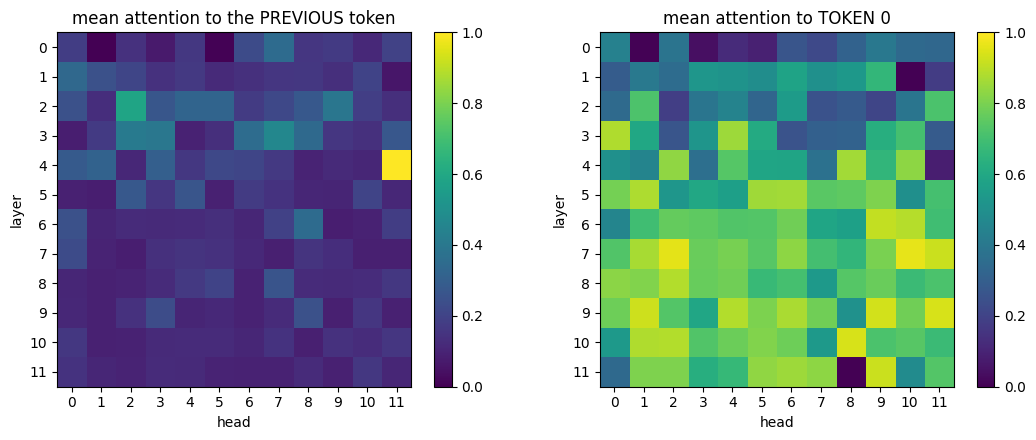

In [5]:
@torch.no_grad()
def get_attention(text: str):
    enc = tok(text, return_tensors="pt")
    out = model(**enc, output_attentions=True)
    assert out.attentions is not None and out.attentions[0] is not None, (
        "no attention weights returned: load the model with attn_implementation='eager'"
    )
    labels = [t.replace("Ġ", "_") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return labels, out.attentions  # 12 tensors, each (batch=1, heads=12, n, n)


TEXT = PROMPT
labels, atts = get_attention(TEXT)
n = len(labels)
print(f"{n} tokens: {labels}")
print(f"{len(atts)} layers; each tensor has shape {tuple(atts[0].shape)} = (batch, heads, query, key)")
print("row sums, layer 0 head 0:", [round(x, 4) for x in atts[0][0, 0].sum(dim=-1).tolist()])

# For every one of the 144 heads: how much attention goes to the PREVIOUS token, and to token 0?
prev_score = torch.zeros(cfg.n_layer, cfg.n_head)
sink_score = torch.zeros(cfg.n_layer, cfg.n_head)
for L in range(cfg.n_layer):
    a = atts[L][0]  # (heads, n, n)
    prev_score[L] = torch.stack([a[:, i, i - 1] for i in range(1, n)]).mean(dim=0)
    sink_score[L] = a[:, 1:, 0].mean(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, score, title in [
    (axes[0], prev_score, "mean attention to the PREVIOUS token"),
    (axes[1], sink_score, "mean attention to TOKEN 0"),
]:
    im = ax.imshow(score.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
    ax.set_xticks(range(cfg.n_head))
    ax.set_yticks(range(cfg.n_layer))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

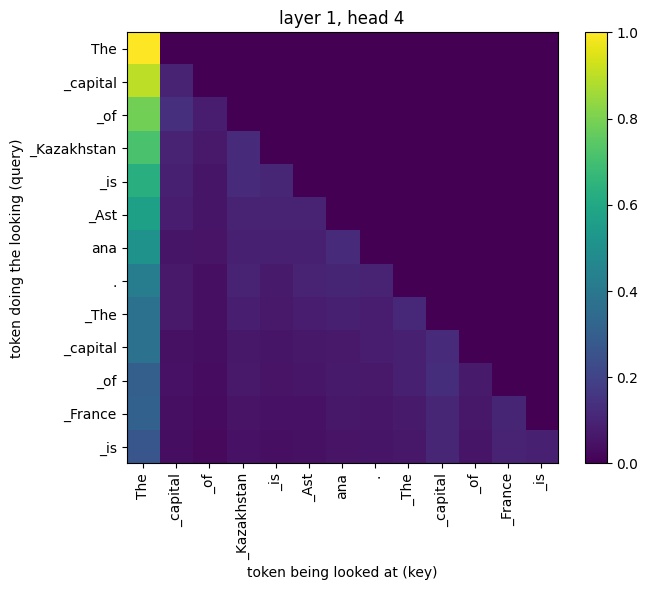

In [6]:
def attention_heatmap(text: str, layer: int, head: int) -> None:
    labels, atts = get_attention(text)
    a = atts[layer][0, head]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(a.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("token being looked at (key)")
    ax.set_ylabel("token doing the looking (query)")
    ax.set_title(f"layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


LAYER, HEAD = 1, 4  # (Layer 1, Head 4 — один из главных previous-token heads в GPT-2)
attention_heatmap(TEXT, LAYER, HEAD)

**✏️ Your answers.**

1. Read the left grid above. Which (layer, head) looks most like a "previous-token" head? Put it into `LAYER, HEAD` in the cell above and re-run it. What pattern do you see in the heatmap, and why is it a diagonal just *below* the main diagonal?
2. Does every head in that layer do the same thing?

> **1.** Layer 4, Head 11 is the clearest "previous-token" head (visible as the bright yellow square near 1.0 on the left grid). The heatmap shows a diagonal shifted exactly one position below the main diagonal because each query token at position i places nearly 100% of its attention weight on the key token at position i-1.
>
> **2.** No, other heads in Layer 4 do not do the same thing. Attention heads are highly specialized—while Head 11 focuses on the previous token, other heads in the same layer attend to token 0 (attention sink), self-positions, or long-range syntactic patterns.

In [7]:
# Check yourself: the three heads with the highest previous-token score for this prompt.
for v, idx in zip(*torch.topk(prev_score.flatten(), 3)):
    L, H = divmod(idx.item(), cfg.n_head)
    print(f"layer {L}, head {H}: {v.item():.3f} of its attention goes to the previous token")

layer 4, head 11: 1.000 of its attention goes to the previous token
layer 2, head 2: 0.585 of its attention goes to the previous token
layer 3, head 7: 0.462 of its attention goes to the previous token


most extreme head on the RIGHT grid: layer 7, head 10  (mean attention to token 0 = 0.964)
mean attention to token 0, averaged over the 12 heads of each layer:
   [0.25, 0.42, 0.4, 0.52, 0.57, 0.72, 0.71, 0.81, 0.74, 0.79, 0.75, 0.66]


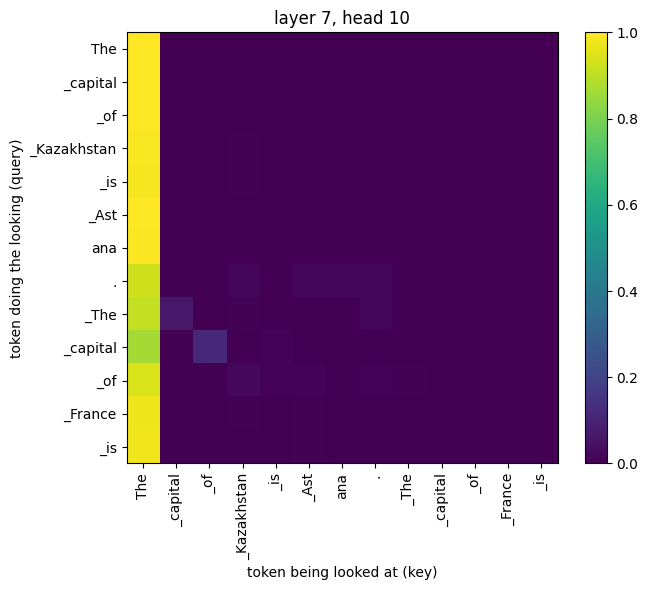

In [8]:
sink_layer, sink_head = divmod(sink_score.argmax().item(), cfg.n_head)
print(f"most extreme head on the RIGHT grid: layer {sink_layer}, head {sink_head}  "
      f"(mean attention to token 0 = {sink_score[sink_layer, sink_head]:.3f})")
print("mean attention to token 0, averaged over the 12 heads of each layer:")
print("  ", [round(x, 2) for x in sink_score.mean(dim=1).tolist()])
attention_heatmap(TEXT, sink_layer, sink_head)

### Two traps

**The bright first column.** In layers 5–10 the *average* head puts roughly 70–80% of its attention on
token 0 (measured above, for this prompt), and the most extreme head puts over 95% there. That is not
"the model is thinking about the word *The*". The usual explanation — which this lab does not test — is that a softmax
row must sum to 1, so a head with nothing useful to look at has to put its weight somewhere, and the first
token is where it goes. Either way, the bright column tells you how the mechanism is built, not what the
first word means. Which head is the most extreme one changes from text to text; the phenomenon does not.

**A weight is not an explanation.** A high attention weight says how much of a token's *value vector* is
averaged in. It does not say how much that token changed the answer. Lecture 3 cited the papers that argue
about this; the heatmap is a picture of a mechanism, not a proof of a reason.

**✏️ Your answer.** Which layers have the highest average attention to token 0? Given the trap above, would you
report "the model focuses on the first word" to a manager? What would you say instead?

> **Answer:** Layers 5 through 10 have the highest average attention to token 0 (peaking at layers 7–9 with 70–81% average attention).
I would NOT report to a manager that "the model focuses on the first word." Instead, I would explain that token 0 acts as an "attention sink"—a structural mechanism where attention heads dump unused probability weight when no specific token in the context requires focus, simply because Softmax forces each row to sum to 1. It reflects how the model stores leftover weight, not that the word "The" carries semantic importance.

## Part 3 — the same model, in Kazakh (5 min)

Lecture 3's claim: Kazakh costs more because of the **table**, not the language. GPT-2's table has only
50,257 entries; how well it covers Russian and Kazakh is what you measure now. Three parallel sentences
(my translations — if you spot an error, say so):

**✏️ Predict first.** Which language needs the most tokens *per character*? Lecture 3 (slide 2) measured Kazakh at
1.7–4.8× the English token count and Russian at 1.2–2.9×, across six tokenizers. Will Kazakh be clearly worse than
Russian on GPT-2 as well?

> **Prediction:** Kazakh text will require significantly more tokens per character than English due to severe BPE token fragmentation, leading to poor context usage and incoherent text generation.

In [9]:
SENTENCES = {
    "en": "The capital of Kazakhstan is Astana.",
    "ru": "Столица Казахстана — Астана.",
    "kk": "Қазақстанның астанасы — Астана.",
}

print(f"{'lang':<5}{'chars':>6}{'bytes':>7}{'tokens':>8}{'tokens/char':>13}{'x English':>11}")
en_tokens = len(tok.encode(SENTENCES["en"]))
for lang, s in SENTENCES.items():
    t = len(tok.encode(s))
    print(f"{lang:<5}{len(s):>6}{len(s.encode()):>7}{t:>8}{t / len(s):>13.2f}{t / en_tokens:>11.2f}")

lang  chars  bytes  tokens  tokens/char  x English
en       36     36       8         0.22       1.00
ru       28     53      31         1.11       3.88
kk       31     59      34         1.10       4.25


In [10]:
@torch.no_grad()
def greedy_continue(prompt: str, n_tokens: int = 20) -> str:
    """Slide 14's loop, written out: pick the #1 token, append it, repeat."""
    ids = tok(prompt, return_tensors="pt")["input_ids"]
    for _ in range(n_tokens):
        next_id = model(input_ids=ids).logits[0, -1].argmax()
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
    return tok.decode(ids[0])


for prompt in ["The capital of Kazakhstan is", "Столица Казахстана —", "Қазақстанның астанасы —"]:
    show_next_token(prompt, k=3)
    top1 = int(next_token_logits(prompt).argmax())
    print(f"  #1 token as raw text: {tok.convert_ids_to_tokens(top1)!r}")
    print("  greedy, 20 tokens:", repr(greedy_continue(prompt)))
    print()

prompt: 'The capital of Kazakhstan is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.98%   id    262   ' the'
   7.63%   id   1363   ' home'
   5.89%   id    257   ' a'
  top-3 hold 22.5%; the other 50,254 tokens share 77.5%
  #1 token as raw text: 'Ġthe'
  greedy, 20 tokens: "The capital of Kazakhstan is the capital of the country's former Soviet Union, and the country's president, Nursultan Nazar"

prompt: 'Столица Казахстана —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  37.79%   id  12466   ' �'
   2.40%   id    198   '\n'
   2.34%   id    220   ' '
  top-3 hold 42.5%; the other 50,254 tokens share 57.5%
  #1 token as raw text: 'ĠÐ'
  greedy, 20 tokens: 'Столица Казахстана — Столица Казахста'

prompt: 'Қазақстанның астанасы —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.54%   id  12466   ' �'
   4.11%   id    220   ' '
   2.39%   id    198   '\n'
  top-3 hold 29.0%; the other 50,254 tokens share 71.0%
  #1 token as raw te

**✏️ Your answer.** One or two sentences. Look at the `tokens/char` column and at the #1 next token for the
Russian and Kazakh prompts. What does the model see, and why does it break? Is the problem the Kazakh
*language*, or something else? What would you change to fix it?

> **Answer:** The model sees fragmented UTF-8 bytes (over 1.1 tokens per character) instead of whole subwords because GPT-2's English-centric BPE tokenizer vocabulary lacks Cyrillic subword merges, causing severe context dilution and repetitive breakdown. The problem is not the Kazakh language itself, but the tokenizer's vocabulary—it can be fixed by retraining the BPE tokenizer on a multilingual corpus containing Kazakh text to build proper subword units before training or fine-tuning the model.

## What you hand in

Download this notebook (*File → Download → .ipynb*) **after** you have run every cell and filled in every ✏️, and upload it to Canvas.

1. The four predictions (Parts 0, 1, temperature, 3), written before you ran the cell, with the measured value next to each.
2. Your one-sentence difference between temperature and top-p.
3. The (layer, head) you found for the previous-token pattern, and the (layer, head) of the most extreme "token 0" head.
4. Your Part 3 answer.

Extension tasks are in the README of this repository. They are optional.